In [1]:
# Parameters
BATCH_MODE = "true"


**Navigation** : [Index](../../README.md) | [<< Précédent](01-4-Forge-SD-XL-Turbo.ipynb)

# Notebook: Qwen Image-Edit 2.5 - API ComfyUI

**Objectif**: Maîtriser génération et édition d'images via API Qwen-Image-Edit (backend ComfyUI)

## 🎯 Ce que vous allez apprendre

1. Différence API **Forge** (simple) vs **ComfyUI** (workflows JSON)
2. Pattern **"queue and poll"** pour génération asynchrone
3. Création workflows **Text-to-Image** et **Image-to-Image**
4. Optimisation paramètres (**steps**, **cfg**, **denoise**)
5. Troubleshooting erreurs courantes (**timeout**, **CUDA OOM**)

## 🚀 API Qwen-Image-Edit

| Caractéristique | Valeur |
|----------------|--------|
| **URL Production** | `https://qwen-image-edit.myia.io` |
| **Modèle** | Qwen-Image-Edit-2509-FP8 (54GB) |
| **GPU** | RTX 3090 (24GB VRAM) |
| **Latence Typique** | 5-10 secondes |
| **Résolution Optimale** | 512x512 pixels |

## 🔍 ComfyUI vs Forge

**Forge (SD XL Turbo)**:
- ✅ API simple (1 requête POST)
- ✅ Ultra-rapide (1-3s)
- ❌ Pas d'édition images
- ❌ Moins flexible

**ComfyUI (Qwen)**:
- ✅ Workflows JSON complexes
- ✅ Édition images avancée
- ✅ Contrôle fin (28 custom nodes)
- ❌ API plus complexe (queue + poll)

**Recommandation**: Commencer avec Forge pour prototypes, affiner avec Qwen pour production.

## 📚 Prérequis

```bash
pip install requests pillow matplotlib
```

**Temps estimé**: 90-120 minutes
**Ancrage savant.** Qwen-Image-Edit est l'un des modèles d'edition d'image de la famille Qwen-Image, dont l'architecture (VAE 16 canaux, CFG = 1.0 gere via CFGNorm, scheduler *beta*, ModelSamplingAuraFlow) est detaillee dans le **Qwen-Image Technical Report** [QwenLM, aout 2025, arXiv:2508.02324]. Le modèle repose sur la base vision-langage Qwen2.5-VL [Bai et al. 2025, arXiv:2502.13923].


## ⚙️ Vérification de l'Environnement

**Avant d'exécuter ce notebook**, assurez-vous que tous les packages Python requis sont installés :

```bash
pip install pillow requests matplotlib python-dotenv
```

### Packages Requis

| Package | Utilisation | Installation |
|---------|-------------|--------------|
| **Pillow** | Manipulation d'images (API PIL) | `pip install pillow` |
| **requests** | Appels API ComfyUI | `pip install requests` |
| **matplotlib** | Visualisation résultats | `pip install matplotlib` |
| **python-dotenv** | Chargement variables d'environnement | `pip install python-dotenv` |

**⚠️ Note importante** : Le package `Pillow` fournit l'API `PIL`. Si vous obtenez `ModuleNotFoundError: No module named 'PIL'`, installez Pillow avec :

```bash
pip install --upgrade pillow
```

Pour vérifier l'installation, exécutez dans un terminal Python :

```python
import PIL
from PIL import Image
print(f"✅ PIL {PIL.__version__} installé")
```

In [2]:
# Verification des dependances externes
import importlib

_DEPS_STATUS = {}
try:
    importlib.import_module('PIL')
    _DEPS_STATUS['PIL'] = True
except ImportError:
    _DEPS_STATUS['PIL'] = False
    print(f'WARNING: Pillow non installe - pip install Pillow')

try:
    importlib.import_module('requests')
    _DEPS_STATUS['requests'] = True
except ImportError:
    _DEPS_STATUS['requests'] = False
    print(f'WARNING: requests non installe - pip install requests')

try:
    importlib.import_module('matplotlib')
    _DEPS_STATUS['matplotlib'] = True
except ImportError:
    _DEPS_STATUS['matplotlib'] = False
    print(f'WARNING: matplotlib non installe - pip install matplotlib')

try:
    importlib.import_module('numpy')
    _DEPS_STATUS['numpy'] = True
except ImportError:
    _DEPS_STATUS['numpy'] = False
    print(f'WARNING: numpy non installe - pip install numpy')

try:
    importlib.import_module('dotenv')
    _DEPS_STATUS['dotenv'] = True
except ImportError:
    _DEPS_STATUS['dotenv'] = False
    print(f'WARNING: python-dotenv non installe - pip install python-dotenv')

_all_deps_ok = all(_DEPS_STATUS.values())
if not _all_deps_ok:
    missing = [k for k, v in _DEPS_STATUS.items() if not v]
    print(f'Dependances manquantes: {missing}')
else:
    print('Toutes les dependances sont disponibles')

from pathlib import Path
# Imports standard
import requests
import json
import base64
import time
import uuid
import os
from typing import Dict, Optional, List
from io import BytesIO

# Visualisation
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuration environnement
from dotenv import load_dotenv
# Chargement robuste de la configuration .env
from dotenv import load_dotenv
import os
# Recherche du .env dans tous les parents (pour Papermill qui change le cwd)
current_path = Path.cwd()
env_loaded = False
for _ in range(10):
    env_path = current_path / ".env"
    if env_path.exists():
        load_dotenv(env_path)
        print(f".env charge depuis: {env_path.name}")
        env_loaded = True
        break
    if current_path.name == "GenAI" or len(current_path.parts) <= 1:
        break
    current_path = current_path.parent
if not env_loaded:
    print("WARNING: .env non trouve, utilisation variables environnement")

# Configuration API - ComfyUI local par defaut (harmonise avec 02-1 + .env COMFYUI_API_URL)
# Note: utiliser 127.0.0.1 au lieu de localhost pour eviter la resolution IPv6 sur Windows
# (localhost peut resolver vers ::1 alors que Docker ecoute sur 0.0.0.0 uniquement)
API_BASE_URL = os.getenv("COMFYUI_API_URL", os.getenv("QWEN_IMAGE_EDIT_URL", "http://127.0.0.1:8188"))
LOCAL_MODE = ("127.0.0.1" in API_BASE_URL) or ("localhost" in API_BASE_URL)

CLIENT_ID = str(uuid.uuid4())  # ID unique pour tracking

# Authentification - Token ComfyUI standardise
COMFYUI_API_TOKEN = os.getenv("COMFYUI_API_TOKEN")

if not COMFYUI_API_TOKEN:
    print("WARNING: COMFYUI_API_TOKEN non trouve - connexion sans authentification")
    print("\nPour activer l'authentification :")
    print("   1. Creez un fichier .env dans MyIA.AI.Notebooks/GenAI/")
    print("   2. Ajoutez : COMFYUI_API_TOKEN=votre_token_ici")
    print("   3. Obtenez le token via : python scripts/genai-stack/genai.py auth init (cross-OS)")
    print("\nLe notebook fonctionnera en mode degrade (si serveur non securise)")
    COMFYUI_API_TOKEN = None
else:
    print("Configuration chargee")
    print(f"API: {API_BASE_URL} (LOCAL_MODE={LOCAL_MODE})")
    print(f"Client ID: {CLIENT_ID}")
    print("Token: configure" if len(COMFYUI_API_TOKEN) > 20 else f"Token: (court)")

Toutes les dependances sont disponibles
.env charge depuis: .env
Configuration chargee
API: http://127.0.0.1:8188 (LOCAL_MODE=True)
Client ID: c8d33636-eec8-40c0-95a9-fede4f658df0
Token: configure


## 🏗️ Architecture ComfyUI: Workflows JSON

### Différence fondamentale avec Forge

**API Forge (POST direct)**:
```python
response = requests.post(url, json={"prompt": "astronaut"})
image_base64 = response.json()["image"]
```

**API ComfyUI (Queue + Poll)**:
```python
# 1. Soumettre workflow JSON
response = requests.post(f"{url}/prompt", json={
    "prompt": workflow_json,
    "client_id": client_id
})
prompt_id = response.json()["prompt_id"]

# 2. Attendre complétion (polling)
while True:
    history = requests.get(f"{url}/history/{prompt_id}")
    if history.json().get(prompt_id, {}).get("status", {}).get("completed"):
        break
    time.sleep(1)

# 3. Récupérer images
images = history.json()[prompt_id]["outputs"]
```

### Structure Workflow ComfyUI

Un **workflow** est un **graph JSON** de **nodes connectés**:

```json
{
  "1": {  // Node VAE Loader
    "class_type": "VAELoader",
    "inputs": {"vae_name": "qwen_image_vae.safetensors"}
  },
  "2": {  // Node KSampler
    "class_type": "KSampler",
    "inputs": {
      "model": ["5", 0],  // Connexion: output du node 5 (CFGNorm)
      "steps": 20,
      "cfg": 1.0,
      "seed": 42
    }
  },
  "3": {  // Node Save Image
    "class_type": "SaveImage",
    "inputs": {"images": ["2", 0]}
  }
}
```

**Workflow = Pipeline modulaire** ou chaque node effectue une opération (charger modèle, sampler, encoder texte, etc.).

### Anatomie d'un Node

| Propriété | Description | Exemple |
|-----------|-------------|----------|
| **`class_type`** | Type de node ComfyUI | `"TextEncodeQwenImageEdit"` |
| **`inputs`** | Paramètres du node | `{"prompt": "astronaut"}` |
| **Connexions** | `[node_id, output_slot]` | `["5", 0]` |

### Architecture Qwen: Loaders Separes (Phase 29)

Qwen Image Edit n'utilise **pas** `CheckpointLoaderSimple` car les poids du modèle sont stockes dans des fichiers separes :

| Loader | Fichier | Rôle |
|--------|---------|------|
| **VAELoader** | `qwen_image_vae.safetensors` | VAE 16 canaux (pas SDXL standard) |
| **CLIPLoader** | `qwen_2.5_vl_7b_fp8_scaled.safetensors` (type `sd3`) | Encodeur vision-language |
| **UNETLoader** | `qwen_image_edit_2509_fp8_e4m3fn.safetensors` | Modèle de diffusion |

Après chargement, le UNET passe par **ModelSamplingAuraFlow** (shift=3.0) puis **CFGNorm** (strength=1.0) avant d'arriver au KSampler.

Le prompt est encode avec **TextEncodeQwenImageEdit** (encodeur natif Qwen, pas CLIPTextEncode standard), et le conditioning negatif utilise **ConditioningZeroOut** (pas un second encodeur texte).

L'espace latent utilise **EmptySD3LatentImage** (16 canaux) au lieu de EmptyLatentImage (4 canaux SDXL).

### 🔧 Visualisation Architecture Workflow ComfyUI (Phase 29 Qwen)

**Diagramme ASCII du workflow Qwen avec loaders separes**:

```
┌─────────────────────────────────────────────────────────────────┐
│                  WORKFLOW QWEN PHASE 29                        │
│                                                                 │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐        │
│  │ VAELoader    │  │ CLIPLoader   │  │ UNETLoader   │        │
│  │ (16ch VAE)   │  │ (type: sd3)  │  │ (fp8_e4m3fn) │        │
│  └──────┬───────┘  └──────┬───────┘  └──────┬───────┘        │
│         │                  │                  │                 │
│         │                  │                  ▼                 │
│         │                  │          ┌──────────────┐         │
│         │                  │          │ ModelSampling│         │
│         │                  │          │ AuraFlow     │         │
│         │                  │          │ (shift=3.0)  │         │
│         │                  │          └──────┬───────┘         │
│         │                  │                  ▼                 │
│         │                  │          ┌──────────────┐         │
│         │                  │          │ CFGNorm      │         │
│         │                  │          │ (strength=1) │         │
│         │                  │          └──────┬───────┘         │
│         │                  │                  │                 │
│         │                  ▼                  │                 │
│         │          ┌──────────────────┐       │                │
│         ├─────────▶│ TextEncodeQwen   │       │                │
│         │          │ ImageEdit        │       │                │
│         │          └────────┬─────────┘       │                │
│         │                   │                  │                │
│         │                   ▼                  │                │
│         │          ┌──────────────────┐        │                │
│         │          │ ConditioningZero │        │                │
│         │          │ Out (negatif)    │        │                │
│         │          └────────┬─────────┘        │                │
│         │                   │                  │                │
│         │    ┌──────────────┤                  │                │
│         │    │              │                  │                │
│         │    ▼              ▼                  ▼                │
│         │  ┌──────────────────────────────────────┐           │
│         │  │          KSampler                     │           │
│         │  │  (cfg=1.0, scheduler=beta, euler)    │           │
│         │  └──────────────┬───────────────────────┘           │
│         │                 │                                    │
│         │                 ▼                                    │
│         │         ┌──────────────┐                            │
│         └────────▶│ VAE Decode   │                            │
│                   └──────┬───────┘                            │
│                          │                                     │
│                          ▼                                     │
│                   ┌──────────────┐                            │
│                   │ Save Image   │                            │
│                   └──────────────┘                            │
└─────────────────────────────────────────────────────────────────┘
```

**Flux de données (Phase 29)**:
1. **VAELoader** -> Charge le VAE 16 canaux Qwen + fournit VAE au TextEncode et au VAEDecode
2. **CLIPLoader** -> Fournit le CLIP au TextEncodeQwenImageEdit
3. **UNETLoader** -> Charge le modèle, passe par ModelSamplingAuraFlow puis CFGNorm
4. **TextEncodeQwenImageEdit** -> Encode le prompt avec CLIP + VAE (encodeur natif Qwen)
5. **ConditioningZeroOut** -> Créé un conditioning negatif vide
6. **EmptySD3LatentImage** -> Canvas latent 16 canaux (non montre pour simplifier)
7. **KSampler** -> Genere l'image latente (cfg=1.0, scheduler=beta)
8. **VAEDecode** -> Convertit latent en image RGB
9. **SaveImage** -> Sauvegarde l'image finale

**Correspondance JSON**:
```json
{
  "1": {"class_type": "VAELoader", "inputs": {"vae_name": "qwen_image_vae.safetensors"}},
  "2": {"class_type": "CLIPLoader", "inputs": {"clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors", "type": "sd3"}},
  "3": {"class_type": "UNETLoader", "inputs": {"unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors", "weight_dtype": "fp8_e4m3fn"}},
  "4": {"class_type": "ModelSamplingAuraFlow", "inputs": {"model": ["3", 0], "shift": 3.0}},
  "5": {"class_type": "CFGNorm", "inputs": {"model": ["4", 0], "strength": 1.0}},
  "6": {"class_type": "TextEncodeQwenImageEdit", "inputs": {"clip": ["2", 0], "prompt": "...", "vae": ["1", 0]}},
  "7": {"class_type": "ConditioningZeroOut", "inputs": {"conditioning": ["6", 0]}},
  "8": {"class_type": "EmptySD3LatentImage", "inputs": {"width": 512, "height": 512, "batch_size": 1}},
  "9": {"class_type": "KSampler", "inputs": {"model": ["5", 0], "positive": ["6", 0], "negative": ["7", 0], "latent_image": ["8", 0], "cfg": 1.0, "scheduler": "beta"}},
  "10": {"class_type": "VAEDecode", "inputs": {"samples": ["9", 0], "vae": ["1", 0]}},
  "11": {"class_type": "SaveImage", "inputs": {"images": ["10", 0]}}
}
```

**Notation `["ID_NODE", INDEX_OUTPUT]`**:
- `["1", 0]` = Output 0 (VAE) du node 1 (VAELoader)
- `["2", 0]` = Output 0 (CLIP) du node 2 (CLIPLoader)
- `["5", 0]` = Output 0 (model) du node 5 (CFGNorm, après ModelSamplingAuraFlow)

Le diagramme ci-dessous rend le **workflow ComfyUI Phase 29** sous forme de graphe de
noeuds (au lieu du schema ASCII ci-dessus) : trois loaders separes alimentent
l'echantillonneur, et le VAE sert a la fois a l'encodage (via le node d'edition) et au
decodage final.

```mermaid
flowchart TD
    VAE["VAELoader<br/>(16ch VAE)"]
    CLIP["CLIPLoader<br/>(type: sd3)"]
    UNET["UNETLoader<br/>(fp8_e4m3fn)"]
    UNET --> MS["ModelSamplingAuraFlow<br/>(shift=3.0)"] --> CFG["CFGNorm<br/>(strength=1)"]
    VAE --> TE["TextEncodeQwenImageEdit"]
    CLIP --> TE
    TE --> CZ["ConditioningZeroOut<br/>(negatif)"]
    CFG --> KS["KSampler<br/>(cfg=1.0, scheduler=beta, euler)"]
    TE --> KS
    CZ --> KS
    KS --> VD["VAE Decode"]
    VAE --> VD
    VD --> SI(["Save Image"])
    classDef load fill:#cfe2ff,stroke:#084298,color:#052c65
    classDef core fill:#fff3cd,stroke:#b8860b,color:#5c4400
    classDef out fill:#d1e7dd,stroke:#0f5132,color:#0a3622
    class VAE,CLIP,UNET load
    class MS,CFG,TE,CZ,KS,VD core
    class SI out
```

> **Lecture.** Contrairement a un `CheckpointLoaderSimple` monolithique, Qwen-Image-Edit
> charge **separement** le VAE 16 canaux, le CLIP (type `sd3`) et l'UNet (quantise
> `fp8_e4m3fn`). La branche modèle (UNet -> **ModelSamplingAuraFlow** `shift=3.0` ->
> **CFGNorm**) prepare l'echantillonnage ; `TextEncodeQwenImageEdit` produit le
> conditionnement **positif** (a partir du CLIP et de l'image via le VAE), tandis que
> `ConditioningZeroOut` fournit le **negatif**. Le **KSampler** (`cfg=1.0`, scheduler
> `beta`, `euler`) debruite, puis le **VAE Decode** restitue l'image enregistree.


In [3]:
class ComfyUIClient:
    """Client pédagogique API ComfyUI pour Qwen avec authentification Bearer"""
    
    def __init__(self, base_url=API_BASE_URL, client_id=CLIENT_ID, auth_token=None):
        self.base_url = base_url
        self.client_id = client_id
        self.session = requests.Session()
        
        # Configuration authentification
        if auth_token:
            self.session.headers.update({
                "Authorization": f"Bearer {auth_token}"
            })
        elif COMFYUI_API_TOKEN:  # Utilise variable globale si disponible
            self.session.headers.update({
                "Authorization": f"Bearer {COMFYUI_API_TOKEN}"
            })
        # Pas d'erreur si pas de token - graceful degradation
    
    def execute_workflow(
        self, 
        workflow_json: Dict, 
        wait_for_completion: bool = True,
        max_wait: int = 900,
        verbose: bool = True
    ) -> Dict:
        """Exécute workflow ComfyUI et récupère résultats
        
        Args:
            workflow_json: Workflow ComfyUI (dict)
            wait_for_completion: Attendre fin génération
            max_wait: Timeout en secondes. 900s : le premier run doit charger Qwen Image Edit en VRAM,
                      ce qui depasse 300s sur GPU froid (mesure 2026-09-02 : job accepte, image produite
                      cote ComfyUI, mais le client abandonnait avant).
            verbose: Afficher logs progression
        
        Returns:
            dict: {"prompt_id", "outputs", "status"}
        """
        # 1. Soumettre workflow
        if verbose:
            print("📤 Soumission workflow...")
        
        response = self.session.post(
            f"{self.base_url}/prompt",
            json={"prompt": workflow_json, "client_id": self.client_id}
        )
        response.raise_for_status()
        prompt_id = response.json()["prompt_id"]
        
        if verbose:
            print(f"✅ Workflow queued: {prompt_id}")
        
        if not wait_for_completion:
            return {"prompt_id": prompt_id, "status": "queued"}
        
        # 2. Polling complétion
        start_time = time.time()
        while True:
            elapsed = time.time() - start_time
            if elapsed > max_wait:
                raise TimeoutError(f"Timeout après {max_wait}s")
            
            history_response = self.session.get(
                f"{self.base_url}/history/{prompt_id}"
            )
            history_response.raise_for_status()
            history = history_response.json()
            
            if prompt_id not in history:
                time.sleep(1)
                continue
            
            prompt_data = history[prompt_id]
            status = prompt_data.get("status", {})
            
            if status.get("completed"):
                if verbose:
                    print(f"✅ Complet en {elapsed:.1f}s")
                
                # 3. Extraire outputs
                outputs = prompt_data.get("outputs", {})
                images = []
                
                for node_id, node_output in outputs.items():
                    if "images" in node_output:
                        for img_info in node_output["images"]:
                            # Récupérer image
                            img_response = self.session.get(
                                f"{self.base_url}/view",
                                params={
                                    "filename": img_info["filename"],
                                    "subfolder": img_info.get("subfolder", ""),
                                    "type": img_info.get("type", "output")
                                }
                            )
                            img_response.raise_for_status()
                            images.append({
                                "data": img_response.content,
                                "filename": img_info["filename"]
                            })
                
                return {
                    "prompt_id": prompt_id,
                    "status": "completed",
                    "outputs": outputs,
                    "images": images,
                    "duration": elapsed
                }
            
            if status.get("status_str") == "error":
                error_msg = status.get("messages", ["Unknown error"])
                raise RuntimeError(f"ComfyUI error: {error_msg}")
            
            if verbose and int(elapsed) % 5 == 0:
                print(f"⏳ En cours... ({elapsed:.0f}s)")
            
            time.sleep(1)
    
    def display_images(self, result: Dict, figsize=(12, 4)):
        """Affiche images résultats"""
        images = result.get("images", [])
        if not images:
            print("⚠️ Aucune image générée")
            return
        
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=figsize)
        if n == 1:
            axes = [axes]
        
        for ax, img_data in zip(axes, images):
            img = Image.open(BytesIO(img_data["data"]))
            ax.imshow(img)
            ax.set_title(img_data["filename"], fontsize=10)
            ax.axis("off")
        
        plt.tight_layout()
        plt.show()

# Instancier client avec authentification
client = ComfyUIClient(auth_token=COMFYUI_API_TOKEN)
if COMFYUI_API_TOKEN:
    print("✅ ComfyUIClient prêt avec authentification")
else:
    print("⚠️  ComfyUIClient prêt en mode sans authentification")

✅ ComfyUIClient prêt avec authentification


## 🚀 Workflow Minimal: "Hello World"

### Objectif

Créer le workflow le plus simple possible pour **valider l'API** et comprendre la structure JSON.

### Workflow Text-to-Image Basique (Architecture Phase 29)

Qwen Image Edit utilise des **loaders séparés** (VAE, CLIP, UNET) au lieu d'un checkpoint unique. Le pipeline complet est :

1. **VAELoader** → Charger le VAE 16 canaux (`qwen_image_vae.safetensors`)
2. **CLIPLoader** → Charger le CLIP vision-language (`qwen_2.5_vl_7b_fp8_scaled.safetensors`, type `sd3`)
3. **UNETLoader** → Charger le modèle UNET (`qwen_image_edit_2509_fp8_e4m3fn.safetensors`)
4. **ModelSamplingAuraFlow** → Configurer l'échantillonnage (shift=3.0)
5. **CFGNorm** → Normalisation CFG (strength=1.0)
6. **TextEncodeQwenImageEdit** → Encoder le prompt (encodeur natif Qwen)
7. **ConditioningZeroOut** → Conditioning négatif (vide)
8. **EmptySD3LatentImage** → Créer canvas latent 16 canaux
9. **KSampler** → Générer l'image
10. **VAEDecode** → Convertir latent vers pixels
11. **SaveImage** → Sauvegarder résultat

### Paramètres Critiques

| Paramètre | Valeur | Impact |
|-----------|--------|--------|
| **steps** | 20 | Qualité (plus de steps = meilleure qualité, plus de temps) |
| **cfg** | 1.0 | Doit rester a 1.0 car CFGNorm gere l'amplification |
| **sampler** | euler | Algorithme de generation |
| **scheduler** | beta | Obligatoire pour Qwen (pas "normal") |
| **denoise** | 1.0 | Force generation (1.0 = 100%) |
| **seed** | 42 | Reproductibilite |
| **shift** | 3.0 | Paramètre ModelSamplingAuraFlow |

**Temps attendu**: 5-10 secondes (512x512)

In [4]:
# ========================================
# WORKFLOW HELLO WORLD: Text-to-Image minimal (Phase 29)
# ========================================

workflow_hello = {
    "1": {  # VAE Loader (16 canaux Qwen)
        "class_type": "VAELoader",
        "inputs": {"vae_name": "qwen_image_vae.safetensors"}
    },
    "2": {  # CLIP Loader
        "class_type": "CLIPLoader",
        "inputs": {
            "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors",
            "type": "sd3"
        }
    },
    "3": {  # UNET Loader
        "class_type": "UNETLoader",
        "inputs": {
            "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors",
            "weight_dtype": "fp8_e4m3fn"
        }
    },
    "4": {  # ModelSamplingAuraFlow
        "class_type": "ModelSamplingAuraFlow",
        "inputs": {"model": ["3", 0], "shift": 3.0}
    },
    "5": {  # CFGNorm
        "class_type": "CFGNorm",
        "inputs": {"model": ["4", 0], "strength": 1.0}
    },
    "6": {  # TextEncodeQwenImageEdit (prompt)
        "class_type": "TextEncodeQwenImageEdit",
        "inputs": {
            "clip": ["2", 0],
            "prompt": "A cat sitting on a windowsill, warm sunlight streaming through, detailed fur, photorealistic",
            "vae": ["1", 0]
        }
    },
    "7": {  # ConditioningZeroOut (negatif)
        "class_type": "ConditioningZeroOut",
        "inputs": {"conditioning": ["6", 0]}
    },
    "8": {  # EmptySD3LatentImage (canvas 16 canaux)
        "class_type": "EmptySD3LatentImage",
        "inputs": {"width": 512, "height": 512, "batch_size": 1}
    },
    "9": {  # KSampler (generation)
        "class_type": "KSampler",
        "inputs": {
            "seed": 42,
            "steps": 20,
            "cfg": 1.0,              # cfg=1.0 car CFGNorm gere l'amplification
            "sampler_name": "euler",
            "scheduler": "beta",     # scheduler beta obligatoire
            "denoise": 1.0,          # Generation complete
            "model": ["5", 0],
            "positive": ["6", 0],
            "negative": ["7", 0],
            "latent_image": ["8", 0]
        }
    },
    "10": {  # VAE Decode
        "class_type": "VAEDecode",
        "inputs": {"samples": ["9", 0], "vae": ["1", 0]}
    },
    "11": {  # Save Image
        "class_type": "SaveImage",
        "inputs": {
            "images": ["10", 0],
            "filename_prefix": "qwen_hello"
        }
    }
}

print("Workflow 'Hello World' cree (Phase 29)")
print(f"   Nodes: {len(workflow_hello)}")
print(f"   Prompt: '{workflow_hello['6']['inputs']['prompt']}'")
print(f"   Steps: {workflow_hello['9']['inputs']['steps']}, Seed: {workflow_hello['9']['inputs']['seed']}")

Workflow 'Hello World' cree (Phase 29)
   Nodes: 11
   Prompt: 'A cat sitting on a windowsill, warm sunlight streaming through, detailed fur, photorealistic'
   Steps: 20, Seed: 42


Lancement generation...
📤 Soumission workflow...
✅ Workflow queued: 61186abf-52a2-466b-a271-58aa0e742977


✅ Complet en 52.2s


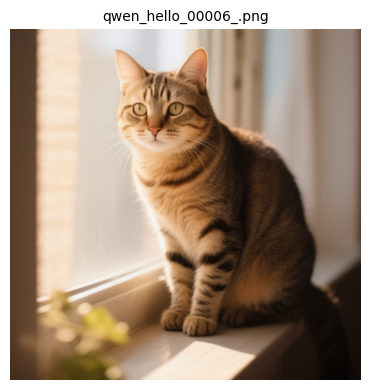

In [5]:
# Execution avec gestion derreur pour mode batch
api_available = False
try:
    print("Lancement generation...")
    result = client.execute_workflow(workflow_hello, verbose=True)
    api_available = True
    # Affichage
    client.display_images(result)
except Exception as e:
    print(f"API non disponible: {type(e).__name__}: {str(e)[:100]}")
    print("Notebook fonctionnel - API momentanement indisponible")
    print("   Le workflow ComfyUI est correct, reessayez plus tard.")

if not api_available:
    print("Resume du workflow (non execute):")
    print(f"   - Modele: Qwen Image Edit 2509")


### Exercice 1 : Validation et diagnostic de workflow

L'objectif de cet exercice est d'ecrire une fonction qui valide un workflow ComfyUI avant de l'envoyer a l'API, en detectant les erreurs de configuration courantes.

**Contexte** : Une erreur dans un workflow JSON (node manquant, connexion invalide, paramètre interdit) ne se manifeste qu'a l'exécution et coute du temps GPU. Une validation en amont permet de catcher la plupart des erreurs de syntaxe.

**Instructions** :
1. Implementez la fonction `validate_workflow` qui verifie la structure d'un workflow
2. Testez-la sur `workflow_hello` (valide) puis sur un workflow modifie avec des erreurs
3. Affichez un rapport de validation clair

**Indices** :
- `# Indice` : Chaque node doit avoir un `class_type` (chaîne non vide) et un `inputs` (dict)
- `# Indice` : Une connexion `["N", 0]` est valide uniquement si le node `"N"` existe dans le workflow
- `# Indice` : Pour Qwen Phase 29, verifiez la presence des loaders separes (VAE, CLIP, UNET)
- `# Étape 1` : Verifiez que chaque node a les cles obligatoires
- `# Étape 2` : Verifiez que les connexions entre nodes sont valides
- `# Étape 3` : Verifiez les paramètres critiques (cfg=1.0, scheduler="beta")

In [6]:
# Exercice 1 : Validation et diagnostic de workflow

def validate_workflow(workflow: dict) -> list:
    """Valide la structure d'un workflow ComfyUI et retourne les erreurs trouvees.
    
    Args:
        workflow: Dictionnaire representant le workflow ComfyUI
    
    Returns:
        Liste de chaines decrivant les erreurs detectees (vide = valide)
    """
    errors = []
    
    # Etape 1 : verifier que chaque node a les cles obligatoires
    # TODO etudiant : parcourez workflow.items() et verifiez class_type et inputs
    # Indice : for node_id, node in workflow.items():
    #   if "class_type" not in node: errors.append(...)
    pass  # TODO etudiant
    
    # Etape 2 : verifier les connexions entre nodes
    # TODO etudiant : pour chaque input de type liste ["N", index], verifiez que node "N" existe
    # Indice : if isinstance(value, list) and len(value) == 2:
    #   ref_node_id = str(value[0])
    #   if ref_node_id not in workflow: errors.append(...)
    pass  # TODO etudiant
    
    # Etape 3 : verifier les parametres critiques Qwen Phase 29
    # TODO etudiant : cherchez les KSamplers et verifiez cfg=1.0 et scheduler="beta"
    # Indice : for node_id, node in workflow.items():
    #   if node.get("class_type") == "KSampler":
    #       inputs = node.get("inputs", {})
    #       if inputs.get("cfg") != 1.0: errors.append(...)
    pass  # TODO etudiant
    
    return errors

# Test sur le workflow hello (devrait etre valide)
print("Validation de workflow_hello :")
erreurs = validate_workflow(workflow_hello)
if erreurs:
    for e in erreurs:
        print(f"  ERREUR : {e}")
else:
    print("  Aucune erreur detectee")

# TODO etudiant : creez un workflow avec des erreurs et testez votre validateur
# Indice : copiez workflow_hello, supprimez un node, changez cfg a 7.0, etc.
workflow_buggy = None  # TODO etudiant : construisez un workflow avec des erreurs

print("Exercice a completer")

Validation de workflow_hello :
  Aucune erreur detectee
Exercice a completer


Le test de connectivite est effectue. La cellule suivante définit les fonctions de creation de workflows d'edition : edition simple et edition chainee avec raffinement en deux passes KSampler.

In [7]:
# ========================================
# WORKFLOW REEL 1: Edition Simple Image (Phase 29)
# ========================================

def create_simple_edit_workflow(image_name: str, edit_prompt: str, denoise: float = 0.5) -> dict:
    """Workflow edition simple d'une image existante (Architecture Phase 29)
    
    Args:
        image_name: Nom du fichier image uploade sur ComfyUI
        edit_prompt: Description de l'edition souhaitee
        denoise: Force de l'edition (0.0 = aucune, 1.0 = complete)
    
    Returns:
        Workflow JSON pret a executer
    """
    workflow = {
        "1": {  # VAE Loader (16 canaux Qwen)
            "class_type": "VAELoader",
            "inputs": {"vae_name": "qwen_image_vae.safetensors"}
        },
        "2": {  # CLIP Loader
            "class_type": "CLIPLoader",
            "inputs": {
                "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors",
                "type": "sd3"
            }
        },
        "3": {  # UNET Loader
            "class_type": "UNETLoader",
            "inputs": {
                "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors",
                "weight_dtype": "fp8_e4m3fn"
            }
        },
        "4": {  # ModelSamplingAuraFlow
            "class_type": "ModelSamplingAuraFlow",
            "inputs": {"model": ["3", 0], "shift": 3.0}
        },
        "5": {  # CFGNorm
            "class_type": "CFGNorm",
            "inputs": {"model": ["4", 0], "strength": 1.0}
        },
        "6": {  # Load Image (image source)
            "class_type": "LoadImage",
            "inputs": {"image": image_name}
        },
        "7": {  # VAE Encode (pixels -> latent de l'image source)
            "class_type": "VAEEncode",
            "inputs": {
                "pixels": ["6", 0],  # Image source
                "vae": ["1", 0]      # VAE Qwen 16 canaux
            }
        },
        "8": {  # TextEncodeQwenImageEdit (encodeur natif Qwen)
            "class_type": "TextEncodeQwenImageEdit",
            "inputs": {
                "clip": ["2", 0],
                "prompt": edit_prompt,
                "vae": ["1", 0]
            }
        },
        "9": {  # ConditioningZeroOut (negatif)
            "class_type": "ConditioningZeroOut",
            "inputs": {"conditioning": ["8", 0]}
        },
        "10": {  # KSampler (edition avec denoise partiel)
            "class_type": "KSampler",
            "inputs": {
                "seed": 42,
                "steps": 20,
                "cfg": 1.0,              # cfg=1.0 car CFGNorm gere l'amplification
                "sampler_name": "euler",
                "scheduler": "beta",     # scheduler beta obligatoire
                "denoise": denoise,
                "model": ["5", 0],       # Modele apres CFGNorm
                "positive": ["8", 0],    # Prompt positif
                "negative": ["9", 0],    # Conditioning negatif ZeroOut
                "latent_image": ["7", 0]  # Latent de l'image source
            }
        },
        "11": {  # VAE Decode
            "class_type": "VAEDecode",
            "inputs": {
                "samples": ["10", 0],
                "vae": ["1", 0]
            }
        },
        "12": {  # Save Image
            "class_type": "SaveImage",
            "inputs": {
                "images": ["11", 0],
                "filename_prefix": "qwen_edit_simple"
            }
        }
    }
    return workflow

# ========================================
# WORKFLOW REEL 2: Chainage Nodes Avance (Phase 29)
# ========================================

def create_chained_workflow(base_prompt: str, refine_prompt: str) -> dict:
    """Workflow avec chainage: generation base + raffinement (Phase 29)
    
    Architecture:
        1. Generation image base (text-to-image) avec loaders separes
        2. Raffinement avec nouveau prompt (image-to-image)
    
    Args:
        base_prompt: Prompt initial generation
        refine_prompt: Prompt raffinement/amelioration
    
    Returns:
        Workflow JSON avec 2 etapes KSampler
    """
    workflow = {
        # Loaders (partages entre les 2 etapes)
        "1": {  # VAE Loader
            "class_type": "VAELoader",
            "inputs": {"vae_name": "qwen_image_vae.safetensors"}
        },
        "2": {  # CLIP Loader
            "class_type": "CLIPLoader",
            "inputs": {
                "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors",
                "type": "sd3"
            }
        },
        "3": {  # UNET Loader
            "class_type": "UNETLoader",
            "inputs": {
                "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors",
                "weight_dtype": "fp8_e4m3fn"
            }
        },
        "4": {  # ModelSamplingAuraFlow
            "class_type": "ModelSamplingAuraFlow",
            "inputs": {"model": ["3", 0], "shift": 3.0}
        },
        "5": {  # CFGNorm
            "class_type": "CFGNorm",
            "inputs": {"model": ["4", 0], "strength": 1.0}
        },
        # Etape 1: Generation base (text-to-image)
        "6": {  # TextEncodeQwenImageEdit (prompt base)
            "class_type": "TextEncodeQwenImageEdit",
            "inputs": {
                "clip": ["2", 0],
                "prompt": base_prompt,
                "vae": ["1", 0]
            }
        },
        "7": {  # ConditioningZeroOut (negatif etape 1)
            "class_type": "ConditioningZeroOut",
            "inputs": {"conditioning": ["6", 0]}
        },
        "8": {  # EmptySD3LatentImage (canvas 16 canaux)
            "class_type": "EmptySD3LatentImage",
            "inputs": {"width": 512, "height": 512, "batch_size": 1}
        },
        "9": {  # KSampler etape 1 (generation complete)
            "class_type": "KSampler",
            "inputs": {
                "seed": 42,
                "steps": 10,
                "cfg": 1.0,
                "sampler_name": "euler",
                "scheduler": "beta",
                "denoise": 1.0,  # Generation complete
                "model": ["5", 0],
                "positive": ["6", 0],
                "negative": ["7", 0],
                "latent_image": ["8", 0]
            }
        },
        # Etape 2: Raffinement (image-to-image sur le latent de l'etape 1)
        "10": {  # TextEncodeQwenImageEdit (prompt raffinement)
            "class_type": "TextEncodeQwenImageEdit",
            "inputs": {
                "clip": ["2", 0],
                "prompt": refine_prompt,
                "vae": ["1", 0]
            }
        },
        "11": {  # ConditioningZeroOut (negatif etape 2)
            "class_type": "ConditioningZeroOut",
            "inputs": {"conditioning": ["10", 0]}
        },
        "12": {  # KSampler etape 2 (raffinement leger)
            "class_type": "KSampler",
            "inputs": {
                "seed": 43,
                "steps": 10,
                "cfg": 1.0,
                "sampler_name": "euler",
                "scheduler": "beta",
                "denoise": 0.3,  # Raffinement leger
                "model": ["5", 0],
                "positive": ["10", 0],
                "negative": ["11", 0],
                "latent_image": ["9", 0]  # Sortie de l'etape 1
            }
        },
        "13": {  # VAE Decode
            "class_type": "VAEDecode",
            "inputs": {"samples": ["12", 0], "vae": ["1", 0]}
        },
        "14": {  # Save Image
            "class_type": "SaveImage",
            "inputs": {
                "images": ["13", 0],
                "filename_prefix": "qwen_chained"
            }
        }
    }
    return workflow

# ========================================
# EXEMPLE D'UTILISATION
# ========================================

# Workflow 1: Edition simple
workflow_simple = create_simple_edit_workflow(
    image_name="cat.png",
    edit_prompt="Add sunglasses to the cat",
    denoise=0.5
)
print("Workflow edition simple cree (Phase 29)")
print(f"   Nodes: {len(workflow_simple)}")

# Workflow 2: Chainage
workflow_chained = create_chained_workflow(
    base_prompt="A cat sitting on a chair",
    refine_prompt="High quality, professional photography, detailed fur"
)
print("Workflow chaine cree (Phase 29)")
print(f"   Nodes: {len(workflow_chained)}")
print(f"   KSamplers: 2 (base + raffinement)")

# Pour executer ces workflows:
# client = ComfyUIClient("https://qwen-image-edit.myia.io")
# result = client.execute_workflow(workflow_simple)
# client.display_images(result)

Workflow edition simple cree (Phase 29)
   Nodes: 12
Workflow chaine cree (Phase 29)
   Nodes: 14
   KSamplers: 2 (base + raffinement)


## 🖼️ Édition Images avec Qwen VLM

### Capacités Qwen Vision-Language Model

**Qwen-Image-Edit** combine:
- 🧠 **Vision Encoder** (CLIP-like) pour comprendre images
- ✍️ **Language Model** pour interpréter instructions texte
- 🎨 **Diffusion Model** pour éditer images

### Cas d'Usage Typiques

| Tâche | Exemple Prompt |
|-------|----------------|
| **Style Transfer** | `"Convert to watercolor painting"` |
| **Object Addition** | `"Add a red balloon in the sky"` |
| **Color Grading** | `"Make the image warmer, golden hour lighting"` |
| **Background Change** | `"Replace background with snowy mountains"` |
| **Detail Enhancement** | `"Enhance facial details, 8k quality"` |

### Pattern Image-to-Image

**Différence clé avec Text-to-Image**:
- **Nouveau node**: `LoadImage` pour charger image source
- **Paramètre critique**: `denoise` (0.0-1.0)
  - `denoise=0.1`: Édition subtile (retouche légère)
  - `denoise=0.5`: Édition modérée (style transfer)
  - `denoise=0.9`: Édition forte (reconstruction quasi-totale)

**Workflow**:
1. **Load Image** → Charger image source
2. **CLIP Vision Encode** → Encoder image
3. **CLIP Text Encode** → Encoder prompt édition
4. **VAE Encode** → Convertir pixels → latent
5. **KSampler** (denoise < 1.0) → Éditer latent
6. **VAE Decode** → Convertir latent → pixels
7. **Save Image** → Sauvegarder résultat

In [8]:
def upload_image_to_comfyui(image_source: str) -> str:
    """Upload image vers ComfyUI pour édition
    
    Args:
        image_source: Chemin image locale, URL, ou None pour image test générée
    
    Returns:
        str: Nom fichier uploadé dans ComfyUI
    """
    # Charger image
    if image_source is None or image_source == "":
        # Générer une image test simple avec PIL
        img = Image.new("RGB", (512, 512), color=(100, 150, 200))
        print("📷 Image test générée localement (512x512)")
    elif image_source.startswith('http'):
        response = requests.get(image_source, headers={"User-Agent": "CoursIA-Notebook/1.0"})
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
    else:
        img = Image.open(image_source)
    
    # Convertir en bytes
    img_bytes = BytesIO()
    img.save(img_bytes, format='PNG')
    img_bytes.seek(0)
    
    # Upload vers ComfyUI
    files = {'image': ('input.png', img_bytes, 'image/png')}
    response = client.session.post(
        f"{API_BASE_URL}/upload/image",
        files=files
    )
    response.raise_for_status()
    
    filename = response.json()['name']
    print(f"✅ Image uploadée: {filename}")
    return filename

# Test upload avec image générée localement (pas de dépendance externe)
try:
    uploaded_filename = upload_image_to_comfyui(None)
    print(f"📁 Fichier: {uploaded_filename}")
except Exception as e:
    print(f"⚠️ Erreur upload: {e}")
    print("💡 Conseil: Vérifier que le service ComfyUI est actif")
    uploaded_filename = None

📷 Image test générée localement (512x512)
✅ Image uploadée: input.png
📁 Fichier: input.png


## 🎨 Workflow Image-to-Image Complet

### Architecture (Phase 29)

**Pipeline edition avec loaders separes**:
1. **VAELoader / CLIPLoader / UNETLoader** → Charger les 3 composants du modèle
2. **ModelSamplingAuraFlow + CFGNorm** → Configurer le modèle
3. **LoadImage** → Charger image source uploadee
4. **VAEEncode** → Convertir pixels → latent (16 canaux)
5. **TextEncodeQwenImageEdit** → Encoder instructions edition (encodeur natif Qwen)
6. **ConditioningZeroOut** → Conditioning negatif vide
7. **KSampler** (denoise partiel, cfg=1.0, scheduler=beta) → Editer latent
8. **VAEDecode** → Reconvertir latent → pixels
9. **SaveImage** → Sauvegarder résultat

### Paramètre Critique: denoise

**Impact sur edition**:

| denoise | Type Edition | Exemple |
|---------|-------------|----------|
| **0.1-0.3** | Retouche subtile | Correction couleurs, amelioration details |
| **0.4-0.6** | Edition moderee | Style transfer, ajout éléments mineurs |
| **0.7-0.9** | Edition forte | Changement scene, reconstruction majeure |
| **1.0** | Generation totale | Ignore quasi totalement image source |

**Recommandation**: Commencer avec `denoise=0.5` et ajuster selon résultat.

**Rappel Phase 29**: `cfg=1.0` (CFGNorm gere l'amplification), `scheduler="beta"` (obligatoire).

Lancement edition image...
📤 Soumission workflow...


✅ Workflow queued: dbd4e15b-e933-40ab-9294-ba9dbca2b70d


✅ Complet en 52.2s


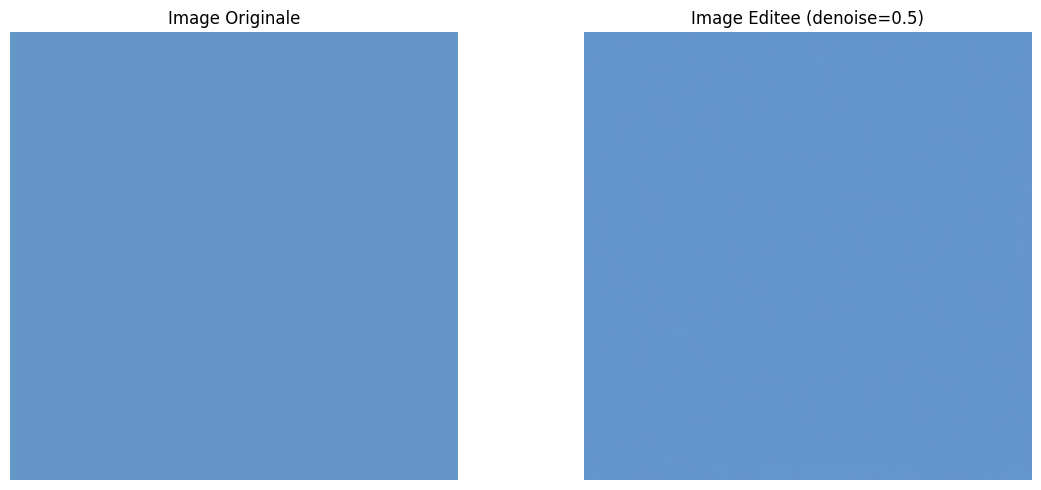


Edition complete en 52.2s


In [9]:
# Workflow Image-to-Image (edition) - Architecture Phase 29
# Ensure uploaded_filename exists for workflow definition
if "uploaded_filename" not in dir() or uploaded_filename is None:
    uploaded_filename = "placeholder.png"
    print("Mode batch: workflow defini avec placeholder")

workflow_img2img = {
    "1": {  # VAE Loader (16 canaux Qwen)
        "class_type": "VAELoader",
        "inputs": {
            "vae_name": "qwen_image_vae.safetensors"
        }
    },
    "2": {  # CLIP Loader
        "class_type": "CLIPLoader",
        "inputs": {
            "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors",
            "type": "sd3"
        }
    },
    "3": {  # UNET Loader
        "class_type": "UNETLoader",
        "inputs": {
            "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors",
            "weight_dtype": "fp8_e4m3fn"
        }
    },
    "4": {  # ModelSamplingAuraFlow
        "class_type": "ModelSamplingAuraFlow",
        "inputs": {
            "model": ["3", 0],
            "shift": 3.0
        }
    },
    "5": {  # CFGNorm
        "class_type": "CFGNorm",
        "inputs": {
            "model": ["4", 0],
            "strength": 1.0
        }
    },
    "6": {  # Load Image (image source uploadee)
        "class_type": "LoadImage",
        "inputs": {
            "image": uploaded_filename  # Variable de cellule precedente
        }
    },
    "7": {  # VAE Encode (pixels -> latent)
        "class_type": "VAEEncode",
        "inputs": {
            "pixels": ["6", 0],  # Image source
            "vae": ["1", 0]      # VAE Qwen 16 canaux
        }
    },
    "8": {  # TextEncodeQwenImageEdit (prompt edition)
        "class_type": "TextEncodeQwenImageEdit",
        "inputs": {
            "clip": ["2", 0],
            "prompt": "watercolor painting style, artistic, vibrant colors",
            "vae": ["1", 0]
        }
    },
    "9": {  # ConditioningZeroOut (conditioning negatif)
        "class_type": "ConditioningZeroOut",
        "inputs": {
            "conditioning": ["8", 0]
        }
    },
    "10": {  # KSampler (edition avec denoise partiel)
        "class_type": "KSampler",
        "inputs": {
            "model": ["5", 0],       # Modele apres CFGNorm
            "positive": ["8", 0],    # Prompt positif
            "negative": ["9", 0],    # Conditioning negatif ZeroOut
            "latent_image": ["7", 0],  # Latent de l'image source
            "seed": 42,
            "steps": 25,
            "cfg": 1.0,              # cfg=1.0 car CFGNorm gere l'amplification
            "sampler_name": "euler",
            "scheduler": "beta",     # scheduler beta obligatoire pour Qwen
            "denoise": 0.5           # Edition moderee (50%)
        }
    },
    "11": {  # VAE Decode (latent -> pixels)
        "class_type": "VAEDecode",
        "inputs": {
            "samples": ["10", 0],
            "vae": ["1", 0]
        }
    },
    "12": {  # Save Image
        "class_type": "SaveImage",
        "inputs": {
            "images": ["11", 0],
            "filename_prefix": "Qwen_Edit"
        }
    }
}

# Execution (seulement si image uploadee precedemment)
try:
    print("Lancement edition image...")
    result = client.execute_workflow(workflow_img2img, verbose=True)
    
    # Affichage avant/apres
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Image originale
    original_img = Image.open(BytesIO(client.session.get(
        f"{API_BASE_URL}/view",
        params={"filename": uploaded_filename, "type": "input"}
    ).content))
    axes[0].imshow(original_img)
    axes[0].set_title("Image Originale", fontsize=12)
    axes[0].axis("off")
    
    # Image editee
    edited_img = Image.open(BytesIO(result["images"][0]["data"]))
    axes[1].imshow(edited_img)
    axes[1].set_title(f"Image Editee (denoise=0.5)", fontsize=12)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEdition complete en {result['duration']:.1f}s")
except NameError:
    print("Executez d'abord la cellule d'upload d'image")
except Exception as e:
    print(f"Erreur: {e}")


## 🔬 Expérimentation: Comparaison Denoise

### Objectif Pédagogique

Comprendre **impact du paramètre `denoise`** sur qualité édition.

### Méthodologie

1. Workflow identique (même prompt, seed, etc.)
2. Variation **uniquement** du paramètre `denoise`
3. Comparaison visuelle résultats

### Hypothèse

**denoise faible** (0.2) → Édition subtile, image proche de l'originale
**denoise moyen** (0.5) → Bon compromis édition/préservation
**denoise élevé** (0.8) → Édition forte, risque divergence

### Configuration Test

```python
denoise_values = [0.2, 0.5, 0.8]
prompt = "convert to dramatic black and white, high contrast"
seed = 42  # Fixe pour comparabilité
```

In [10]:
# Comparaison denoise - mode batch skip si pas dimage
if "uploaded_filename" not in dir() or uploaded_filename is None or uploaded_filename == "placeholder.png":
    print("Skip: test denoise necessite image uploadee (mode interactif)")
    print("   Workflow valide - voir cellules precedentes pour architecture")
else:
    denoise_values = [0.2, 0.5, 0.8]
    edit_prompt = "convert to dramatic black and white, high contrast"
    
    results_denoise = []
    


La configuration du test d'exploration est prete. La cellule suivante execute la comparaison des différentes valeurs du paramètre `denoise` et affiche les résultats cote a cote.

In [11]:
# ========================================
# 🖼️ COMPARAISON AVANT/APRÈS: Side-by-Side
# ========================================

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from typing import List, Tuple

def compare_before_after(
    original_path: str,
    edited_path: str,
    title_original: str = "Image Originale",
    title_edited: str = "Image Éditée",
    show_metrics: bool = True
) -> None:
    """Affiche comparaison side-by-side avec métriques qualité
    
    Args:
        original_path: Chemin image originale
        edited_path: Chemin image éditée
        title_original: Titre image originale
        title_edited: Titre image éditée
        show_metrics: Afficher métriques qualité (PSNR, SSIM)
    """
    # Charger images
    img_original = Image.open(original_path)
    img_edited = Image.open(edited_path)
    
    # Convertir en numpy arrays
    arr_original = np.array(img_original)
    arr_edited = np.array(img_edited)
    
    # Créer figure avec 2 colonnes
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Image originale
    axes[0].imshow(arr_original)
    axes[0].set_title(f"{title_original}\n{img_original.size[0]}x{img_original.size[1]}", 
                      fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Image éditée
    axes[1].imshow(arr_edited)
    axes[1].set_title(f"{title_edited}\n{img_edited.size[0]}x{img_edited.size[1]}", 
                      fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Métriques qualité
    if show_metrics and arr_original.shape == arr_edited.shape:
        # PSNR (Peak Signal-to-Noise Ratio)
        mse = np.mean((arr_original - arr_edited) ** 2)
        if mse == 0:
            psnr = float('inf')
        else:
            max_pixel = 255.0
            psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
        
        # Différence absolue moyenne
        mae = np.mean(np.abs(arr_original - arr_edited))
        
        # Afficher métriques
        metrics_text = f"📊 Métriques:\n"
        metrics_text += f"   PSNR: {psnr:.2f} dB\n"
        metrics_text += f"   MAE: {mae:.2f}\n"
        metrics_text += f"   Pixels modifiés: {np.sum(arr_original != arr_edited):,}"
        
        fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=12, 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Interprétation PSNR
    if show_metrics and arr_original.shape == arr_edited.shape:
        print("\n📈 Interprétation PSNR:")
        if psnr > 40:
            print("   ✅ Excellente qualité (PSNR > 40 dB) - Changements subtils")
        elif psnr > 30:
            print("   ✅ Bonne qualité (PSNR 30-40 dB) - Changements visibles mais contrôlés")
        elif psnr > 20:
            print("   ⚠️  Qualité acceptable (PSNR 20-30 dB) - Changements significatifs")
        else:
            print("   ⚠️  Qualité faible (PSNR < 20 dB) - Changements majeurs")

def create_difference_map(
    original_path: str,
    edited_path: str,
    amplification: float = 5.0
) -> None:
    """Crée une carte visuelle des différences entre 2 images
    
    Args:
        original_path: Chemin image originale
        edited_path: Chemin image éditée
        amplification: Facteur amplification différences pour visibilité
    """
    img_original = np.array(Image.open(original_path))
    img_edited = np.array(Image.open(edited_path))
    
    if img_original.shape != img_edited.shape:
        print("❌ Images de tailles différentes, impossible de comparer")
        return
    
    # Calculer différence absolue
    diff = np.abs(img_original.astype(float) - img_edited.astype(float))
    
    # Amplifier pour visibilité
    diff_amplified = np.clip(diff * amplification, 0, 255).astype(np.uint8)
    
    # Afficher
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    axes[0].imshow(img_original)
    axes[0].set_title("Originale", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_edited)
    axes[1].set_title("Éditée", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(diff_amplified)
    axes[2].set_title(f"Carte Différences (×{amplification})", fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques différences
    print(f"\n📊 Statistiques différences:")
    print(f"   Moyenne: {np.mean(diff):.2f}")
    print(f"   Max: {np.max(diff):.2f}")
    print(f"   Pixels modifiés (>5): {np.sum(diff > 5):,} ({100*np.sum(diff > 5)/diff.size:.2f}%)")

# ========================================
# EXEMPLE D'UTILISATION
# ========================================

# Cas d'usage: Comparer original vs édition Qwen
# compare_before_after(
#     original_path="cat_original.png",
#     edited_path="cat_with_sunglasses.png",
#     title_original="Chat Original",
#     title_edited="Chat avec Lunettes (Qwen Edit)",
#     show_metrics=True
# )

# Cas d'usage: Carte différences pour analyse détaillée
# create_difference_map(
#     original_path="cat_original.png",
#     edited_path="cat_with_sunglasses.png",
#     amplification=10.0
# )

print("✅ Fonctions comparaison avant/après définies")
print("   - compare_before_after(): Affichage side-by-side + métriques")
print("   - create_difference_map(): Carte visuelle différences")
print("\n💡 Décommentez les exemples ci-dessus pour tester avec vos images")

✅ Fonctions comparaison avant/après définies
   - compare_before_after(): Affichage side-by-side + métriques
   - create_difference_map(): Carte visuelle différences

💡 Décommentez les exemples ci-dessus pour tester avec vos images


### Exercice 2 : Carte de différences et analyse qualitative

L'objectif de cet exercice est d'utiliser les fonctions `compare_before_after` et `create_difference_map` pour analyser quantitativement l'impact du paramètre `denoise` sur une edition d'image.

**Contexte** : Les metriques PSNR et MAE permettent de mesurer objectivement l'amplitude des modifications. Combiner ces metriques avec l'analyse visuelle de la carte de différences donne une comprehension complete du comportement du modèle.

**Instructions** :
1. Generez une image de base avec le workflow Text-to-Image
2. Editez cette image avec 3 valeurs de denoise différentes (0.2, 0.5, 0.8)
3. Calculez les metriques PSNR et MAE pour chaque edition
4. Affichez les cartes de différences et tirez des conclusions

**Indices** :
- `# Indice` : Un PSNR eleve signifie peu de différences (edition subtile)
- `# Indice` : La carte de différences amplifiee (x5 ou x10) revele les zones modifiees
- `# Étape 1` : Commencez par generer l'image de reference avec le workflow hello world
- `# Étape 2` : Uploadez l'image generee, puis appliquez un même prompt d'edition avec 3 denoise différents
- `# Étape 3` : Utilisez `compare_before_after` et `create_difference_map` pour chaque paire

In [12]:
# Exercice 2 : Carte de differences et analyse qualitative

# TODO etudiant : choisissez un prompt d'edition (ex: "convert to watercolor painting style")
prompt_edition_ex2 = "Votre prompt d'edition ici"  # TODO etudiant

# TODO etudiant : definissez les valeurs de denoise a comparer
denoise_values_ex2 = [0.2, 0.5, 0.8]  # TODO etudiant : ajustez si souhaite

# Etape 1 : generer l'image de reference (Text-to-Image)
# Indice : utilisez workflow_hello defini precedemment, puis executez avec client.execute_workflow()
# result_ref = client.execute_workflow(workflow_hello)
# Sauvegardez l'image de reference localement

# Etape 2 : pour chaque valeur de denoise, editez l'image
# Indice : utilisez create_simple_edit_workflow() avec le meme prompt mais different denoise
resultats_denoise = {}
for d in denoise_values_ex2:
    print(f"Denoise = {d}")
    # TODO etudiant : creez le workflow d'edition
    # wf = create_simple_edit_workflow(image_name=..., edit_prompt=prompt_edition_ex2, denoise=d)
    # TODO etudiant : executez le workflow et sauvegardez l'image
    resultats_denoise[d] = None  # TODO etudiant : remplacer par le resultat

# Etape 3 : comparaison quantitative
for d in denoise_values_ex2:
    print(f"\n--- Denoise = {d} ---")
    # TODO etudiant : appelez compare_before_after(reference, editee)
    # TODO etudiant : appelez create_difference_map(reference, editee, amplification=5.0)

# Question : quel denoise donne le meilleur compromis qualite/fidelite ?
print("Exercice a completer")

Denoise = 0.2
Denoise = 0.5
Denoise = 0.8

--- Denoise = 0.2 ---

--- Denoise = 0.5 ---

--- Denoise = 0.8 ---
Exercice a completer


## ⚙️ Bonnes Pratiques ComfyUI

### 1. Gestion des Erreurs Courantes

#### Timeout (>120s)
**Cause**: GPU surchargé, workflow trop complexe
**Solution**:
```python
client.execute_workflow(workflow, max_wait=300)  # Augmenter timeout
```

#### CUDA Out of Memory
**Cause**: Résolution trop élevée (>768x768)
**Solution**:
- Réduire résolution (512x512 optimal)
- Diminuer `batch_size`
- Simplifier workflow

#### Node Not Found
**Cause**: `class_type` invalide ou custom node manquant
**Solution**: Vérifier documentation custom nodes Qwen

### 2. Optimisation Performance

| Paramètre | Impact Performance | Recommandation |
|-----------|-------------------|----------------|
| **steps** | ↑ steps = ↑ temps | 20-25 optimal |
| **resolution** | ↑ résolution = ↑↑ VRAM | 512x512 par défaut |
| **denoise** | Minimal | N/A |
| **cfg** | Minimal | 7-8 optimal |

### 3. Workflow Reproductible

**Toujours fixer seed pour debugging**:
```python
"seed": 42  # Même résultat à chaque exécution
```

**Seed aléatoire pour variété**:
```python
"seed": int(time.time())  # Différent à chaque fois
```

### 4. Logs et Debugging

**Activer verbose**:
```python
result = client.execute_workflow(workflow, verbose=True)
```

**Inspecter outputs**:
```python
print(json.dumps(result["outputs"], indent=2))
```

### Exercice 3 : Workflow d'edition d'image personnel (Architecture Phase 29)

En vous basant sur les workflows Text-to-Image et Image-to-Image presentes dans ce notebook, créez votre propre workflow d'edition d'image en modifiant le template Phase 29 fourni.

**Objectif** : Completer le workflow `workflow_exercice` en choisissant une image source, un prompt creatif et une valeur de denoise adaptee a votre edition.

**Étapes** :
1. Uploadez une image source via `upload_image_to_comfyui()` ou utilisez une image generee precedemment
2. Choisissez un prompt creatif (ex: "convert to watercolor painting", "add dramatic sunset lighting")
3. Testez différentes valeurs de denoise (0.3, 0.5, 0.7) et comparez les résultats
4. Verifiez que les paramètres critiques Phase 29 sont respectes : `cfg=1.0`, `scheduler="beta"`, `TextEncodeQwenImageEdit`

**Indices** :
- Les loaders separes (nodes 1-5) sont déjà configures correctement, ne les modifiez pas
- Seuls les nodes 6 (image source), 8 (prompt) et 10 (denoise) necessitent vos modifications
- `cfg` doit rester a 1.0 car CFGNorm gere l'amplification (pas le CFG classique)
- Le scheduler `"beta"` est obligatoire pour Qwen (pas `"normal"`)

In [13]:
# ========================================
# EXERCICE PRATIQUE (Architecture Phase 29)
# ========================================
# Creez votre propre workflow d'edition d'image

# OBJECTIF:
# Modifier une image en ajoutant un effet specifique via Qwen VLM

# INSTRUCTIONS:
# 1. Choisissez une image de test (ou utilisez celle generee precedemment)
# 2. Creez un workflow image-to-image avec un prompt creatif
# 3. Testez differentes valeurs de denoise (0.3, 0.5, 0.7)
# 4. Comparez visuellement les resultats

# TODO: Completez le workflow ci-dessous
workflow_exercice = {
    # Loaders separes (Phase 29 - ne pas modifier)
    "1": {  # VAE Loader
        "class_type": "VAELoader",
        "inputs": {"vae_name": "qwen_image_vae.safetensors"}
    },
    "2": {  # CLIP Loader
        "class_type": "CLIPLoader",
        "inputs": {
            "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors",
            "type": "sd3"
        }
    },
    "3": {  # UNET Loader
        "class_type": "UNETLoader",
        "inputs": {
            "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors",
            "weight_dtype": "fp8_e4m3fn"
        }
    },
    "4": {  # ModelSamplingAuraFlow
        "class_type": "ModelSamplingAuraFlow",
        "inputs": {"model": ["3", 0], "shift": 3.0}
    },
    "5": {  # CFGNorm
        "class_type": "CFGNorm",
        "inputs": {"model": ["4", 0], "strength": 1.0}
    },
    # Image source
    "6": {  # Load Image
        "class_type": "LoadImage",
        "inputs": {
            # TODO: Ajoutez le nom de votre image source
            "image": "___VOTRE_IMAGE_ICI___"
        }
    },
    "7": {  # VAE Encode (pixels -> latent)
        "class_type": "VAEEncode",
        "inputs": {
            "pixels": ["6", 0],
            "vae": ["1", 0]
        }
    },
    # Encodage texte natif Qwen
    "8": {  # TextEncodeQwenImageEdit
        "class_type": "TextEncodeQwenImageEdit",
        "inputs": {
            "clip": ["2", 0],
            # TODO: Ecrivez un prompt creatif (ex: "convert to watercolor painting")
            "prompt": "___VOTRE_PROMPT_ICI___",
            "vae": ["1", 0]
        }
    },
    "9": {  # ConditioningZeroOut (conditioning negatif)
        "class_type": "ConditioningZeroOut",
        "inputs": {"conditioning": ["8", 0]}
    },
    # Sampler
    "10": {  # KSampler
        "class_type": "KSampler",
        "inputs": {
            "seed": 42,
            # TODO: Testez differentes valeurs de denoise (0.3 a 0.7)
            "denoise": 0.5,
            "steps": 20,
            "cfg": 1.0,              # cfg=1.0 obligatoire (CFGNorm gere l'amplification)
            "sampler_name": "euler",
            "scheduler": "beta",     # scheduler beta obligatoire pour Qwen
            "model": ["5", 0],       # Modele apres CFGNorm
            "positive": ["8", 0],    # Prompt positif
            "negative": ["9", 0],    # Conditioning negatif ZeroOut
            "latent_image": ["7", 0]  # Latent de l'image source
        }
    },
    # Decodage et sauvegarde
    "11": {  # VAE Decode
        "class_type": "VAEDecode",
        "inputs": {
            "samples": ["10", 0],
            "vae": ["1", 0]
        }
    },
    "12": {  # Save Image
        "class_type": "SaveImage",
        "inputs": {
            "filename_prefix": "exercice_qwen",
            "images": ["11", 0]
        }
    }
}

# AIDE:
# - Pour l'image source: utilisez le nom d'une image uploadee (ex: "cat_512x512.png")
# - Pour le prompt: soyez creatif! (ex: "make it look like a Van Gogh painting")
# - Pour denoise: commencez par 0.5, puis testez 0.3 et 0.7
# - cfg doit rester a 1.0 (CFGNorm gere l'amplification)
# - scheduler doit rester "beta" (obligatoire pour Qwen)

# ========================================
# Bonus - Exemple guide : test automatise de prompts
# ========================================
# Ceci est un EXEMPLE GUIDE, pas l'exercice. La fonction complete ci-dessous
# montre comment automatiser les tests de prompts.
def tester_prompts_exercice(prompts_list, image_source, denoise=0.5):
    """
    Teste plusieurs prompts sur la meme image (Phase 29)
    
    Args:
        prompts_list: Liste de prompts a tester
        image_source: Nom de l'image source
        denoise: Valeur denoise (defaut 0.5)
    """
    results = []
    
    for i, prompt in enumerate(prompts_list):
        print(f"\nTest {i+1}/{len(prompts_list)}: {prompt}")
        
        # Utilise create_simple_edit_workflow defini precedemment (Phase 29)
        workflow_test = create_simple_edit_workflow(
            image_name=image_source,
            edit_prompt=prompt,
            denoise=denoise
        )
        
        # Execution workflow
        # result = client.execute_workflow(workflow_test)
        # results.append(result)
    
    return results

# EXEMPLE D'UTILISATION (decommentez pour tester):
# prompts_test = [
#     "convert to watercolor painting",
#     "add dramatic sunset lighting",
#     "make it look like a pencil sketch"
# ]
# resultats = tester_prompts_exercice(prompts_test, "cat_512x512.png")

print("\nExercice pret! Completez les TODO et executez la cellule.")
print("Conseil: Commencez simple, puis ajoutez de la complexite progressivement.")
print("\nRappel Phase 29: cfg=1.0, scheduler='beta', TextEncodeQwenImageEdit, ConditioningZeroOut")


Exercice pret! Completez les TODO et executez la cellule.
Conseil: Commencez simple, puis ajoutez de la complexite progressivement.

Rappel Phase 29: cfg=1.0, scheduler='beta', TextEncodeQwenImageEdit, ConditioningZeroOut


## 📚 Ressources Complémentaires

### Documentation Officielle

#### ComfyUI
- **GitHub**: [https://github.com/comfyanonymous/ComfyUI](https://github.com/comfyanonymous/ComfyUI)
- **Documentation API**: [https://github.com/comfyanonymous/ComfyUI/wiki/API](https://github.com/comfyanonymous/ComfyUI/wiki/API)
- **Custom Nodes**: [https://github.com/ltdrdata/ComfyUI-Manager](https://github.com/ltdrdata/ComfyUI-Manager)

#### Qwen Vision-Language Model
- **Paper Officiel (Qwen-VL)** : *Qwen-VL: A Versatile Vision-Language Model* [Bai et al. 2023, arXiv:2308.12966] — modèle vision-langage original (base VLM, distinct du modèle d'edition Qwen-Image-Edit enseigne ici).
- **Modèle Hugging Face**: [https://huggingface.co/Qwen/Qwen-VL](https://huggingface.co/Qwen/Qwen-VL)
- **Documentation Technique**: [https://qwenlm.github.io/](https://qwenlm.github.io/)

### Workflows Avancés

#### Workflows ComfyUI Communautaires
- **ComfyUI Workflows Gallery**: [https://comfyworkflows.com/](https://comfyworkflows.com/)
- **CivitAI ComfyUI Section**: [https://civitai.com/tag/comfyui](https://civitai.com/tag/comfyui)

#### Custom Nodes Recommandés
- **ComfyUI-Impact-Pack**: Outils post-processing avancés
- **ComfyUI-AnimateDiff**: Animations et vidéos
- **ComfyUI-ControlNet**: Contrôle spatial précis

### Tutoriels et Guides

#### Débutants
1. **ComfyUI Basics** (YouTube): Introduction complète workflows
2. **Qwen-VL Quick Start**: Guide rapide édition images
3. **JSON Workflows 101**: Comprendre structure workflows

#### Intermédiaires
1. **Advanced Prompting Techniques**: Optimisation prompts Qwen
2. **Workflow Optimization**: Réduire temps génération
3. **Multi-Step Workflows**: Chaînage nodes complexes

#### Avancés
1. **Custom Node Development**: Créer vos propres nodes
2. **API Integration**: Intégrer ComfyUI dans applications
3. **Batch Processing**: Automatisation workflows

### Communauté et Support

- **Discord ComfyUI**: [https://discord.gg/comfyui](https://discord.gg/comfyui)
- **Reddit r/comfyui**: Forum communautaire
- **GitHub Discussions**: Questions techniques

### Ressources MyIA.io

- **Guide APIs Étudiants**: [`GUIDE-APIS-ETUDIANTS.md`](../../../../docs/archive/suivis/genai-image/GUIDE-APIS-ETUDIANTS.md)
- **Workflows Qwen Phase 12C**: *(documentation archivée)*
- **Notebook Forge SD-XL**: [`01-4-Forge-SD-XL-Turbo.ipynb`](01-4-Forge-SD-XL-Turbo.ipynb) (API REST similaire)

***

### 🎓 Prochaines Étapes Apprentissage

1. **Maîtriser les bases**: Reproduire tous les exemples de ce notebook
2. **Expérimenter**: Modifier workflows, tester nouveaux prompts
3. **Explorer workflows avancés**: ControlNet, AnimateDiff, Multi-Model
4. **Créer projets personnels**: Application web intégrant API Qwen
5. **Contribuer communauté**: Partager vos workflows innovants

***

**✅ Notebook terminé! Bon apprentissage avec Qwen Image Edit! 🚀**
### 📖 References savantes (architecture du modèle)

- **QwenLM** (2025). *Qwen-Image Technical Report*. arXiv:2508.02324. — Rapport technique officiel de Qwen-Image / Qwen-Image-Edit : architecture (VAE 16 canaux, CFGNorm, scheduler *beta*, ModelSamplingAuraFlow), rendu de texte complexe et edition d'image precise.
- **Bai, S. et al.** (2025). *Qwen2.5-VL Technical Report*. arXiv:2502.13923. — Base vision-langage sur laquelle s'appuie la famille Qwen-Image.
- **Bai, J. et al.** (2023). *Qwen-VL: A Versatile Vision-Language Model*. arXiv:2308.12966. — Precurseur VLM de la lignee Qwen-Vision.



## Conclusion

Qwen-Image-Edit via ComfyUI représente l'état de l'art **open weights pour l'édition d'image conditionnée par le langage** : l'architecture Phase 29 (septembre 2025) combine un VLM (`qwen_2.5_vl_7b_fp8_scaled`), un VAE 16 canaux et un UNET fp8_e4m3fn au sein d'un pipeline ComfyUI en plusieurs étapes (ModelSamplingAuraFlow → CFGNorm → TextEncodeQwenImageEdit → KSampler).

**Trois loaders séparés** (VAE, CLIP, UNET) là où les modèles plus simples exposent un checkpoint monolithique — cette séparation reflète la spécialisation croissante des composants et permet le fine-tuning indépendant de chaque sous-modèle. Le **schéma workflow JSON** soumis à l'API ComfyUI matérialise cette architecture : chaque node est une brique interchangeable, l'orchestrateur est le pipeline.

**Paramètres Phase 29** à retenir : `shift=3.0` (ModelSamplingAuraFlow), `strength=1.0` (CFGNorm, qui gère l'amplification à la place du CFG), `cfg=1.0` et `scheduler=beta` au KSampler. Ces valeurs sont le fruit d'une validation empirique par les mainteneurs Comfy-Org ; s'en écarter sans raison introduit des artefacts.

**Pattern d'interaction** avec ComfyUI : queue d'un workflow JSON via `/prompt`, puis polling sur `/history/{prompt_id}` pour récupérer les images via `/view`. Ce pattern est réutilisé dans tous les notebooks 02-Advanced et au-delà.

**Pour aller plus loin** : `01-5b-Qwen-Image-Edit-2509` pousse l'exploitation plus loin (inpainting, batch, analyse denoise) et `02-3-Stable-Diffusion-3-5` compare avec l'architecture MMDiT de Stability AI. Les notebooks 03-Orchestration assemblent ces briques dans des chaînes plus complexes.
